In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y = pd.Series(data.target, name="label")

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Target Classes:", data.target_names)


Dataset Shape: (569, 30)
Number of Features: 30
Target Classes: ['malignant' 'benign']


In [3]:
print(X.head())
print("\nMissing Values:")
print(X.isnull().sum().sum())
print("\nClass Distribution:")
print(y.value_counts())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

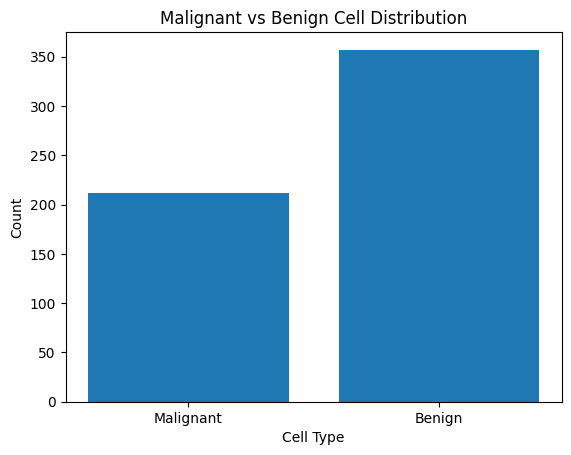

In [4]:
labels = ["Malignant", "Benign"]
counts = [
    (y == 0).sum(),
    (y == 1).sum()
]

plt.bar(labels, counts)
plt.xlabel("Cell Type")
plt.ylabel("Count")
plt.title("Malignant vs Benign Cell Distribution")
plt.show()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (455, 30)
Testing Data: (114, 30)


In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("Model Training Completed!")


Model Training Completed!


In [8]:
y_pred = model.predict(X_test_scaled)

print("First 10 Predictions:")
print(y_pred[:10])


First 10 Predictions:
[0 1 0 1 0 1 1 0 0 0]


In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy * 100, "%")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Model Accuracy: 98.24561403508771 %
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  1]
 [ 1 71]]


In [13]:
# Malignant — Precision: 0.98, Recall: 0.98, F1-score: 0.98, Support: 42
# Benign — Precision: 0.99, Recall: 0.99, F1-score: 0.99, Support: 72

In [14]:
[[41, 1], [1, 71]]

[[41, 1], [1, 71]]

In [11]:
def predict_cell(features):
    features_scaled = scaler.transform([features])
    prediction = model.predict(features_scaled)
    return data.target_names[prediction[0]]

sample = X_test.iloc[0].values
result = predict_cell(sample)
print("Prediction:", result)


Prediction: malignant


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
